# 非稳态多臂老虎机

在非稳态问题中，各臂的**真实价值 q*(a) 会随时间变化**。因此：
- **样本均值**（等权平均）：对旧数据给相同权重，难以跟踪变化
- **常数步长**（指数近因加权）：对近期样本更敏感，通常更适合非稳态问题

In [1]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

## 非稳态老虎机环境

在 Bandit 基础上，每次 `play` 时向 `self.rates` 添加一个小随机数（`0.1 * np.random.randn(arms)`），使各臂胜率随时间变动，即**非稳态问题**。

In [2]:
class NonStatBandit:
    """非稳态老虎机：每次 play 时 rates 添加随机扰动。"""

    def __init__(self, arms=10):
        self.arms = arms
        self.rates = np.random.rand(arms)

    def play(self, arm):
        rate = self.rates[arm]
        self.rates += 0.1 * np.random.randn(self.arms)  # 每次游戏时 rates 漂移
        if rate > np.random.rand():
            return 1
        else:
            return 0

## 两种更新策略

1. **样本均值**：$Q_{n+1} = Q_n + \frac{1}{n}(R_n - Q_n)$，步长 $\alpha_n = 1/n$
2. **常数步长**：$Q_{n+1} = Q_n + \alpha(R_n - Q_n)$，步长 $\alpha$ 固定

In [3]:
class SampleAverageAgent:
    """ε-greedy + 样本均值（等权）。"""

    def __init__(self, epsilon: float, action_size: int = 10):
        self.epsilon = epsilon
        self.Qs = np.zeros(action_size)
        self.ns = np.zeros(action_size)

    def update(self, action: int, reward: float) -> None:
        self.ns[action] += 1
        alpha = 1.0 / self.ns[action]
        self.Qs[action] += alpha * (reward - self.Qs[action])

    def get_action(self) -> int:
        if np.random.rand() < self.epsilon:
            return np.random.randint(0, len(self.Qs))
        return int(np.argmax(self.Qs))


class AlphaAgent:
    """ε-greedy + 常数步长 α 更新。"""

    def __init__(self, epsilon, alpha, actions=10):
        self.epsilon = epsilon
        self.Qs = np.zeros(actions)
        self.alpha = alpha

    def update(self, action, reward):
        self.Qs[action] += (reward - self.Qs[action]) * self.alpha

    def get_action(self):
        if np.random.rand() < self.epsilon:
            return np.random.randint(0, len(self.Qs))
        return np.argmax(self.Qs)

## 单次运行示例

In [4]:
np.random.seed(42)
steps = 10000
arms = 10

bandit = NonStatBandit(arms=arms)
agent_alpha = AlphaAgent(epsilon=0.1, alpha=0.1, actions=arms)
agent_sa = SampleAverageAgent(epsilon=0.1, action_size=arms)

rewards_const = []
rewards_sa = []

for step in range(steps):
    # AlphaAgent（常数步长）
    a_alpha = agent_alpha.get_action()
    r_alpha = bandit.play(a_alpha)
    agent_alpha.update(a_alpha, r_alpha)
    rewards_const.append(r_alpha)

    # 样本均值（同一 bandit，每次 play 时 rates 会漂移）
    a_sa = agent_sa.get_action()
    r_sa = bandit.play(a_sa)
    agent_sa.update(a_sa, r_sa)
    rewards_sa.append(r_sa)

print("AlphaAgent（常数步长）平均奖励:", np.mean(rewards_const))
print("样本均值 平均奖励:", np.mean(rewards_sa))

AlphaAgent（常数步长）平均奖励: 0.9533
样本均值 平均奖励: 0.9535


## 多次运行取平均

In [7]:
runs = 200
steps = 1000
arms = 10
epsilon = 0.1

alphas = [0.1, 0.2, 0.3]
results = {}  # {alpha: avg_rewards}

for alpha in alphas:
    all_rewards = np.zeros((runs, steps))
    for run in range(runs):
        bandit = NonStatBandit(arms=arms)
        agent = AlphaAgent(epsilon=epsilon, alpha=alpha, actions=arms)
        for step in range(steps):
            action = agent.get_action()
            reward = bandit.play(action)  # play 内部会漂移 rates
            agent.update(action, reward)
            all_rewards[run, step] = reward
    results[alpha] = np.mean(all_rewards, axis=0)

# 样本均值作为对照
all_rewards_sa = np.zeros((runs, steps))
for run in range(runs):
    bandit = NonStatBandit(arms=arms)
    agent = SampleAverageAgent(epsilon=epsilon, action_size=arms)
    for step in range(steps):
        action = agent.get_action()
        reward = bandit.play(action)
        agent.update(action, reward)
        all_rewards_sa[run, step] = reward
results["样本均值"] = np.mean(all_rewards_sa, axis=0)

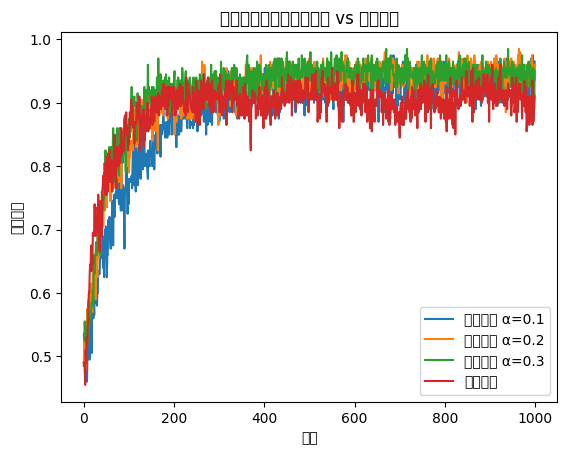

In [8]:
colors = ["tab:blue", "tab:orange", "tab:green", "tab:red"]
labels = [f"Constant step α={a}" for a in alphas] + ["Sample average"]
for (key, avg_rewards), color, label in zip(results.items(), colors, labels):
    plt.plot(avg_rewards, label=label, color=color)
plt.ylabel("Average reward")
plt.xlabel("Steps")
plt.legend()
plt.title("Non-stationary bandit: Constant step vs Sample average")
plt.show()